### [Classical Machine Learning](https://medium.com/ai-ml-interview-playbook/welcome-to-classical-machine-learning-b884ff138547)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings("ignore")

In [2]:
# toy example
df = pd.DataFrame({
    "age": [25, 35, None, 50],
    "income": [50000, 80000, 60000, None],
    "city": ["A", "B", "A", "C"],
    "target": [0, 1, 0, 1]
})
display(df)

num_cols = ["age", "income"]
cat_cols = ["city"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

X = df.drop(columns=["target"])
y = df["target"]
X_transformed = preprocessor.fit_transform(X)
display(pd.DataFrame(X_transformed))

,age,income,city,target
0,25.0,50000.0,A,0
1,35.0,80000.0,B,1
2,NaN,60000.0,A,0
3,50.0,NaN,C,1


,0,1,2,3,4
0,-1.260252,-1.147079,1.0,0.0,0.0
1,-0.140028,1.605910,0.0,1.0,0.0
2,-0.140028,-0.229416,1.0,0.0,0.0
3,1.540308,-0.229416,0.0,0.0,1.0


In [3]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_reg, y_reg = make_regression(n_samples=200, n_features=5, noise=10.0, random_state=0)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, random_state=0)
model = LinearRegression().fit(X_reg_train, y_reg_train)
preds = model.predict(X_reg_test)
print("MSE", mean_squared_error(y_reg_test, preds))

MSE 155.9673728774036


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.metrics import roc_auc_score

X_cls, y_cls = make_classification(n_samples=300, n_features=10, random_state=0)
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(X_cls, y_cls, random_state=0)
clf = LogisticRegression(max_iter=1000).fit(X_cls_train, y_cls_train)
probs = clf.predict_proba(X_cls_test)[:,1]
print("ROC AUC", roc_auc_score(y_cls_test, probs))

ROC AUC 0.9864285714285714


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [6]:
from sklearn.linear_model import Ridge, Lasso

# Transform X_train and X_test using the preprocessor
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

ridge = Ridge(alpha=1.0).fit(X_train_processed, y_train)
lasso = Lasso(alpha=0.1).fit(X_train_processed, y_train)

In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3).fit(X_train_processed, y_train)
print("Accuracy", knn.score(X_test_processed, y_test))

Accuracy 0.0


In [8]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=4).fit(X_train_processed, y_train)
display(tree)

DecisionTreeClassifier(max_depth=4)

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=0).fit(X_train_processed, y_train)
print("RF accuracy", rf.score(X_test_processed, y_test))

RF accuracy 0.0


In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier().fit(X_train_processed, y_train)
print("GB accuracy", gb.score(X_test_processed, y_test))

GB accuracy 0.0


In [11]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", probability=True).fit(X_train_processed, y_train)
display(svm)

SVC(probability=True)

In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans

X, _ = make_classification(n_samples=200, n_features=4, random_state=0)
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
labels = kmeans.labels_

In [13]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2).fit_transform(X)

In [14]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(RandomForestClassifier(), X_cls, y_cls, cv=5, scoring="roc_auc")
print("Mean AUC", scores.mean())

Mean AUC 0.9883299962921764


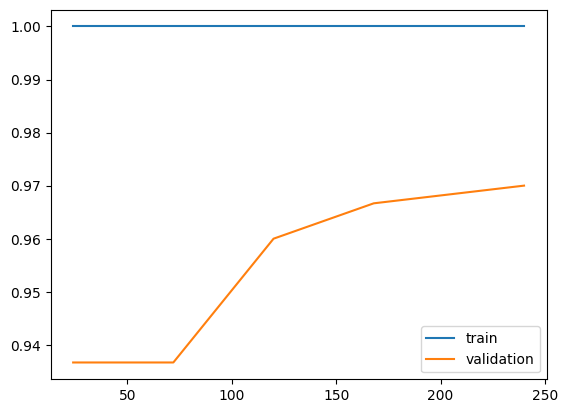

In [15]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(), X_cls, y_cls, cv=5, scoring="accuracy", train_sizes=[0.1,0.3,0.5,0.7,1.0]
)
plt.plot(train_sizes, train_scores.mean(axis=1), label="train")
plt.plot(train_sizes, val_scores.mean(axis=1), label="validation")
plt.legend()

In [16]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier())
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city'])])),
                ('clf', RandomForestClassifier())])

In [17]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {"n_estimators":[100,200,500], "max_depth":[None,5,10,20]}
search = RandomizedSearchCV(RandomForestClassifier(), param_dist, n_iter=10, cv=3)
search.fit(X_cls, y_cls)
print(search.best_params_)

{'n_estimators': 100, 'max_depth': None}
